<a href="https://colab.research.google.com/github/aarti-311/AI-ML-Labs/blob/main/Credit_Score_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. PREPARATION : LIBRARIES

In [ ]:
# libraries for dataframe manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

# libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# library to make bold characters in the output cells
import sys
!{sys.executable} -m pip install termcolor
from termcolor import colored

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#Machine Learning Libraries
# library to split a dataframe into Train and Test dataframes
from sklearn.model_selection import train_test_split

# libraries for feature selection
from sklearn.feature_selection import SelectKBest
    # 1. ANOVA
from sklearn.feature_selection import f_classif
    # 2. Kendall's Tau
from scipy.stats import kendalltau
    # 3. Chi-Squared
from sklearn.feature_selection import chi2
    # 4. Mutual Information
from sklearn.feature_selection import mutual_info_classif
# library to help selecting the best parameter configuration for the model
from sklearn.model_selection import GridSearchCV

# libraries to build the machine learning models
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [ ]:
# original train dataset to serve as reset checkpoint
train_ori = pd.read_csv('train.csv')

# copy of train dataset
train = train_ori.copy()

# original test dataset to serve as reset checkpoint
test_ori = pd.read_csv('test.csv')

# copy of test dataset
test = test_ori.copy()

In [ ]:
# Data Exploration Functions

def missing_values_perc(df):
    # a function to return each datafame column's missing value count and its percentange

    # calculating the missing values for each column
    missing_values = df.isnull().sum()

    # turning the previous output into a dataframe format
    missing_values = pd.DataFrame(missing_values)
    missing_values = missing_values.reset_index()
    missing_values.columns = ['Column', 'Count']

    # calculating each feature's missing values percentage
    list_missing_values = []
    for i in missing_values['Count']:
        missing_values_perc = i / len(df) * 100 # Total entries = 100000 (from previous step)
        list_missing_values.append(missing_values_perc)
    list_missing_values = [round(num, 2) for num in list_missing_values]

    # adding the missing values percentage column to the report
    missing_values['Percentage (%)'] = list_missing_values

    # displaying the missing values report
    print('Missing values on each column : ', '\n')
    print(missing_values.to_string(index = False))

In [ ]:
def uniquevalueprob(dataset, feature, excludeditem = None):
    # a function to get each unique value's count and portion in a feature

    # getting the feature's unique values
    global listUV
    listUV = list(dataset[feature].unique())
    listUV = [i for i in listUV if type(i) is not float]
    if excludeditem is not None:
        listUV.remove(excludeditem)
    else:
        listUV = listUV

    # getting the count of each unique value
    global listUVcount
    listUVcount = []
    for UV in listUV:
        UVcount = (dataset[feature] == UV).sum()
        listUVcount.append(UVcount)
    # calculating the total count of items in the feature
    totalcount = sum(listUVcount)

    # calculating the portion of each unique value
    global listUVportion
    listUVportion = []
    for item in listUVcount:
        UVportion = item / totalcount
        listUVportion.append(UVportion)

    # creating the report table
    table = pd.DataFrame(list(zip(listUV, listUVcount, listUVportion)))
    table.columns = [feature, 'Count', 'Portion']

    # displaying the report table
    print(table.sort_values(['Count', feature],
                            ascending = [0,1]).to_string(index = False))

In [ ]:
# Feature Cleaning Function

def countoutlier(dataset, feature):
    # a function to count how many outliers are present in a numerical list

    # calculating the outlier boundaries
    Q1 = dataset[feature].quantile(0.25)
    Q3 = dataset[feature].quantile(0.75)
    IQR = Q3 - Q1
    UBoundary = Q3 + 1.5 * IQR
    LBoundary = Q1 - 1.5 * IQR

    # counting the outliers
    outliercount = 0
    for i in dataset[feature]:
        if i > UBoundary or i < LBoundary:
            outliercount = outliercount + 1
        else:
            pass

    # displaying the outliers count report
    print('Outlier count in', feature, ':', outliercount)

In [ ]:
def omitoutlier(dataframe, feature):
    # a function to omit outliers that are present in a numerical list

    # calculating the outlier boundaries
    Q1 = dataframe[feature].quantile(0.25)
    Q3 = dataframe[feature].quantile(0.75)
    IQR = Q3 - Q1
    UBoundary = Q3 + 1.5 * IQR
    LBoundary = Q1 - 1.5 * IQR

    # creating a new list that does not contain the outliers
    newlist = []
    for i in dataframe[feature]:
        if i > UBoundary or i < LBoundary:
            newlist.append(np.nan)
        else:
            newlist.append(i)

    # replacing the items in the feature with the newly-created list
    dataframe[feature] = newlist

    # displaying the outliers ommission report
    print(feature, ' data distribution after dropping the outliers : ')
    plt.hist(dataframe[feature])
    plt.title(feature + ' Data Distribution')
    plt.xlabel(feature)
    plt.ylabel('Count')

In [ ]:
def lookupreplacement(dataset, reference, feature):
    # a function to replace all entries in each subgroup of a numerical list based on each subgroup's mode

    # preparing a dataframe containing both the feature that needs the replacement and the reference feature that acts as the lookup table
    lookup = dataset[[reference, feature]]

    # returning the mode of each subgroup that is present in the reference feature
    lookup = lookup.groupby(reference).agg(pd.Series.mode)

    # replacing all entries in each subgroup of the numerical list based on each subgroup's mode
    dataset[feature] = dataset[reference].map(lookup[feature])

    # eliminating any array-type value generated by the replacement method using only the first member of the array value
    newlist = []
    for i in range(len(dataset[feature])):
        # for float type members
        if type(dataset[feature][i]) == np.float64:
            newlist.append(dataset[feature][i])
        # for empty list members
        elif type(dataset[feature][i]) == np.ndarray and len(dataset[feature][i]) == 0:
            newlist.append(np.nan)
        # for non-empty list members
        elif type(dataset[feature][i]) == np.ndarray and len(dataset[feature][i]) != 0:
            newlist.append(dataset[feature][i][1])
    dataset[feature] = newlist

    # reconverting the feature into float to make sure the data type is correct
    dataset[feature].astype(float)

    # displaying the remaining missing value after the replacement and array elimination process
    remaining = dataset[feature].isnull().sum()
    print('Remaining', feature, 'missing values :', remaining)

In [ ]:
def aggregatedfillna(dataset, reference, feature):
    # a function to fill nan entries present in each subgroup of a numerical list using the subgroup's mean +- standard deviation

    # preparing a dataframe containing both the feature that needs the nan filling and the reference feature that acts as the lookup table
    table = dataset[[reference, feature]]

    # locating the nan entries in the feature that needs the nan filling, followed by their reference value
    ref = table.loc[table[feature].isnull(), reference]

    # getting only the unique reference values
    ref = ref.unique()

    # converting the reference values into a list
    ref = list(ref)

    # creating a list with the same length as the reference values list containing empty values
    fe = []
    for i in range(len(ref)):
        fe.append(np.nan)
    # preparing the lookup table containing the reference values and the soon-to-be generated value associated to them
    featureLookup = pd.DataFrame(list(zip(ref, fe)))
    featureLookup.columns = [reference, feature]

    # calculating the mean value of the feature that needs the nan filling
    featureMean = dataset[feature].mean()

    # calculating the standard deviation value of the feature that needs the nan filling
    featureStdDev = dataset[feature].std()

    # generating the lookup value in the lokup table
    featureLookup[feature] = featureLookup[feature].fillna(pd.Series(np.random.randint(int(featureMean - featureStdDev),
                                                                                       int(featureMean + featureStdDev),
                                                                                       size = featureLookup[feature].isnull().sum())))

    # filling in the nan entries in the feature that needs the nan filling with the reference to the lookup table
    dataset[feature] = dataset[feature].fillna(dataset[reference].map(featureLookup.set_index(reference)[feature]))

    # checking if there are still missing values in the feature
    remaining = dataset[feature].isnull().sum()
    print('Remaining', feature, 'missing values :', remaining)

II. Data Exploration Phase I: Get to Know the Data

In [ ]:
# taking a quick look at Train dataframe
pd.set_option('display.max_columns', None)
display(train.head())
print('Rows x cols of train dataframe :', train.shape)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


Rows x cols of train dataframe : (30395, 28)


In [ ]:
# taking a quick look at Test dataframe
display(test.head())
print('Rows x cols of train dataframe :', test.shape)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


Rows x cols of train dataframe : (30701, 27)


In [ ]:
# general overview of the Train dataframe
display(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30395 entries, 0 to 30394
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        30395 non-null  object 
 1   Customer_ID               30395 non-null  object 
 2   Month                     30395 non-null  object 
 3   Name                      27350 non-null  object 
 4   Age                       30395 non-null  object 
 5   SSN                       30395 non-null  object 
 6   Occupation                30395 non-null  object 
 7   Annual_Income             30395 non-null  object 
 8   Monthly_Inhand_Salary     25845 non-null  float64
 9   Num_Bank_Accounts         30395 non-null  int64  
 10  Num_Credit_Card           30395 non-null  int64  
 11  Interest_Rate             30395 non-null  int64  
 12  Num_of_Loan               30395 non-null  object 
 13  Type_of_Loan              26931 non-null  object 
 14  Delay_

None

In [ ]:
# general overview of Test dataframe
display(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30701 entries, 0 to 30700
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        30701 non-null  object 
 1   Customer_ID               30701 non-null  object 
 2   Month                     30701 non-null  object 
 3   Name                      27583 non-null  object 
 4   Age                       30701 non-null  object 
 5   SSN                       30701 non-null  object 
 6   Occupation                30701 non-null  object 
 7   Annual_Income             30701 non-null  object 
 8   Monthly_Inhand_Salary     26080 non-null  float64
 9   Num_Bank_Accounts         30701 non-null  int64  
 10  Num_Credit_Card           30701 non-null  int64  
 11  Interest_Rate             30701 non-null  int64  
 12  Num_of_Loan               30701 non-null  object 
 13  Type_of_Loan              27249 non-null  object 
 14  Delay_

None

In [ ]:
# reporting Train's missing values
missing_values_perc(train)


Missing values on each column :  

                  Column  Count  Percentage (%)
                      ID      0            0.00
             Customer_ID      0            0.00
                   Month      0            0.00
                    Name   3045           10.02
                     Age      0            0.00
                     SSN      0            0.00
              Occupation      0            0.00
           Annual_Income      0            0.00
   Monthly_Inhand_Salary   4550           14.97
       Num_Bank_Accounts      0            0.00
         Num_Credit_Card      0            0.00
           Interest_Rate      0            0.00
             Num_of_Loan      0            0.00
            Type_of_Loan   3464           11.40
     Delay_from_due_date      0            0.00
  Num_of_Delayed_Payment   2149            7.07
    Changed_Credit_Limit      0            0.00
    Num_Credit_Inquiries    594            1.95
              Credit_Mix      1            0.00
     

In [ ]:
# reporting Test's missing values
missing_values_perc(test)

Missing values on each column :  

                  Column  Count  Percentage (%)
                      ID      0            0.00
             Customer_ID      0            0.00
                   Month      0            0.00
                    Name   3118           10.16
                     Age      0            0.00
                     SSN      0            0.00
              Occupation      0            0.00
           Annual_Income      0            0.00
   Monthly_Inhand_Salary   4621           15.05
       Num_Bank_Accounts      0            0.00
         Num_Credit_Card      0            0.00
           Interest_Rate      0            0.00
             Num_of_Loan      0            0.00
            Type_of_Loan   3452           11.24
     Delay_from_due_date      0            0.00
  Num_of_Delayed_Payment   2170            7.07
    Changed_Credit_Limit      0            0.00
    Num_Credit_Inquiries    629            2.05
              Credit_Mix      0            0.00
     

In [ ]:
# duplicated entries in Train dataframe
DuplicatedValues = train.duplicated().sum()
print('Duplicated data (train) : ' + str(DuplicatedValues))

Duplicated data (train) : 0


In [ ]:
# duplicated entries in Test dataframe
DuplicatedValues = test.duplicated().sum()
print('Duplicated data (test) : ' + str(DuplicatedValues))

Duplicated data (test) : 0


In [ ]:
#unique values
# getting the feature names in a list
trainCols = list(train.columns.values)

# calculating the number of each feature's unique values
ListUniqueC = []
for i in train.columns:
    UCount = len(train[i].unique())
    ListUniqueC.append(UCount)

# creating the unique values table
UniqueCTable = pd.DataFrame(list(zip(trainCols, ListUniqueC)))
UniqueCTable.columns = ['Feature', 'Unique Values']

# printing the report
print('Unique values in each feature (train):')
print(UniqueCTable.to_string(index = False))

Unique values in each feature (train):
                 Feature  Unique Values
                      ID          30395
             Customer_ID           3800
                   Month              8
                    Name           3552
                     Age            636
                     SSN           3801
              Occupation             16
           Annual_Income           5735
   Monthly_Inhand_Salary           4021
       Num_Bank_Accounts            340
         Num_Credit_Card            584
           Interest_Rate            597
             Num_of_Loan            145
            Type_of_Loan           2220
     Delay_from_due_date             73
  Num_of_Delayed_Payment            269
    Changed_Credit_Limit           3280
    Num_Credit_Inquiries            460
              Credit_Mix              5
        Outstanding_Debt           4077
Credit_Utilization_Ratio          30395
      Credit_History_Age            405
   Payment_of_Min_Amount              4
 

In [ ]:
# getting the feature names in a list
testCols = list(test.columns.values)

# calculating the number of each feature's unique values
ListUniqueC = []
for i in test.columns:
    UCount = len(test[i].unique())
    ListUniqueC.append(UCount)

# creating the unique values table
UniqueCTable = pd.DataFrame(list(zip(testCols, ListUniqueC)))
UniqueCTable.columns = ['Feature', 'Unique Values']

# printing the report
print('Unique values in each feature (test):')
print(UniqueCTable.to_string(index = False))

Unique values in each feature (test):
                 Feature  Unique Values
                      ID          30701
             Customer_ID           7676
                   Month              4
                    Name           6717
                     Age            646
                     SSN           7677
              Occupation             16
           Annual_Income           9903
   Monthly_Inhand_Salary           7875
       Num_Bank_Accounts            383
         Num_Credit_Card            581
           Interest_Rate            603
             Num_of_Loan            174
            Type_of_Loan           4146
     Delay_from_due_date             73
  Num_of_Delayed_Payment            302
    Changed_Credit_Limit           3474
    Num_Credit_Inquiries            487
              Credit_Mix              4
        Outstanding_Debt           7861
Credit_Utilization_Ratio          30701
      Credit_History_Age            400
   Payment_of_Min_Amount              4
  

In [ ]:
#Feature Engineering: Cleaning Data Type

# categorical features that are supposedly to be numerical instead
FeaturesToConvert = ['Age',
                     'Annual_Income',
                     'Num_of_Loan',
                     'Num_of_Delayed_Payment',
                     'Changed_Credit_Limit',
                     'Outstanding_Debt',
                     'Amount_invested_monthly',
                     'Monthly_Balance']
# 'Credit_History_Age' feature will be dealt with later

# checking the unique values of these features
for feature in FeaturesToConvert:
    uniques = train[feature].unique()
    print('Feature:', '\n',
          colored(feature, attrs = ['bold']), '\n',
          uniques, '\n',
          '--'*40, '\n')

Feature: 
 Age 
 ['23' '-500' '28_' '28' '34' '54' '55' '21' '31' '33' '34_' '7580' '30'
 '30_' '24' '24_' '44' '45' '40' '41' '32' '33_' '35' '35_' '36' '39' '37'
 '181' '20' '46' '26' '42' '19' '31_' '48' '995' '40_' '37_' '38' '54_'
 '5079' '43' '21_' '22' '6409' '16' '7080' '18' '849' '3885' '20_' '15'
 '27' '43_' '38_' '25' '3052' '14' '5342' '17' '18_' '4431' '2657' '2111_'
 '46_' '47' '1032' '16_' '19_' '47_' '456' '5717' '53_' '53' '56' '25_'
 '27_' '55_' '3169' '1191' '29' '42_' '7140' '48_' '49' '49_' '8233'
 '6955' '2534' '3115' '7657' '51' '50' '5112' '50_' '32_' '6452' '2744'
 '22_' '17_' '1439' '29_' '5795' '4872' '1772' '15_' '1383' '5657' '52'
 '1934' '51_' '8352' '3734' '26_' '2056' '39_' '7508' '2339' '14_' '8406'
 '1424' '36_' '6953' '5626' '4471' '548' '44_' '769' '5490' '525' '4202'
 '3665' '7670_' '4670' '3616' '6922' '6619' '1808' '7992' '45_' '223'
 '1232' '4659' '6895' '395' '7099' '6048' '3936' '3512' '123' '5639' '471'
 '7359' '23_' '4049' '5053' '2109' '7183

By looking at some of the entries above, one thing that could be noticed is that some of these entries contain non-numerical character, such as '-' and '_', while they are supposed to have only numerical character. We will omit both of these special characters from the features, and see if they can be converted into numerical features afterwards.

In [ ]:
# removing the '-' and '_' characters
for feature in FeaturesToConvert:
    train[feature] = train[feature].str.strip('-_')
    test[feature] = test[feature].str.strip('-_')

# handling the empty members in each feature
for feature in FeaturesToConvert:
    train[feature] = train[feature].replace({'':np.nan})
    test[feature] = test[feature].replace({'':np.nan})

# trying converting the categorical features into numerical type
for feature in FeaturesToConvert:
    train[feature] = train[feature].astype('float64')
    test[feature] = test[feature].astype('float64')

# checking if the conversion is successful
for feature in FeaturesToConvert:
    print('train dataframe:', feature, '\n',
          train[feature].dtype)
    print('test dataframe :', feature, '\n',
          test[feature].dtype, '\n')

train dataframe: Age 
 float64
test dataframe : Age 
 float64 

train dataframe: Annual_Income 
 float64
test dataframe : Annual_Income 
 float64 

train dataframe: Num_of_Loan 
 float64
test dataframe : Num_of_Loan 
 float64 

train dataframe: Num_of_Delayed_Payment 
 float64
test dataframe : Num_of_Delayed_Payment 
 float64 

train dataframe: Changed_Credit_Limit 
 float64
test dataframe : Changed_Credit_Limit 
 float64 

train dataframe: Outstanding_Debt 
 float64
test dataframe : Outstanding_Debt 
 float64 

train dataframe: Amount_invested_monthly 
 float64
test dataframe : Amount_invested_monthly 
 float64 

train dataframe: Monthly_Balance 
 float64
test dataframe : Monthly_Balance 
 float64 



In [ ]:
#Cleaning Strings in Credit_History_Age to be Numerical

# taking a quick look again at the data
train['Credit_History_Age'].head()

0    22 Years and 1 Months
1                      NaN
2    22 Years and 3 Months
3    22 Years and 4 Months
4    22 Years and 5 Months
Name: Credit_History_Age, dtype: object

In [ ]:
#Data Exploration 2: Categorical Features
# rechecking the general overview of the Train dataframe after it has been previously modified
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30395 entries, 0 to 30394
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        30395 non-null  object 
 1   Customer_ID               30395 non-null  object 
 2   Month                     30395 non-null  object 
 3   Name                      27350 non-null  object 
 4   Age                       30395 non-null  float64
 5   SSN                       30395 non-null  object 
 6   Occupation                30395 non-null  object 
 7   Annual_Income             30395 non-null  float64
 8   Monthly_Inhand_Salary     25845 non-null  float64
 9   Num_Bank_Accounts         30395 non-null  int64  
 10  Num_Credit_Card           30395 non-null  int64  
 11  Interest_Rate             30395 non-null  int64  
 12  Num_of_Loan               30395 non-null  float64
 13  Type_of_Loan              26931 non-null  object 
 14  Delay_

In [ ]:
# rechecking the general overview of the Test dataframe after it has been previously modified
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30701 entries, 0 to 30700
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        30701 non-null  object 
 1   Customer_ID               30701 non-null  object 
 2   Month                     30701 non-null  object 
 3   Name                      27583 non-null  object 
 4   Age                       30701 non-null  float64
 5   SSN                       30701 non-null  object 
 6   Occupation                30701 non-null  object 
 7   Annual_Income             30701 non-null  float64
 8   Monthly_Inhand_Salary     26080 non-null  float64
 9   Num_Bank_Accounts         30701 non-null  int64  
 10  Num_Credit_Card           30701 non-null  int64  
 11  Interest_Rate             30701 non-null  int64  
 12  Num_of_Loan               30701 non-null  float64
 13  Type_of_Loan              27249 non-null  object 
 14  Delay_

In [ ]:
# storing the categorical column name into a list
CatFeatures = []
for feature in train.columns:
    if train[feature].dtype == 'object':
        CatFeatures.append(feature)

# storing the numerical column name into a list
NumFeatures = []
for feature in train.columns:
    if train[feature].dtype == 'float64' or train[feature].dtype == 'int64':
        NumFeatures.append(feature)

In [ ]:
#Item spelling checking
# checking the unique values of categorical features in train dataframe
for feature in CatFeatures:
    uniques = train[feature].unique()
    print('Feature:', '\n',
          colored(feature, attrs = ['bold']), '\n',
          uniques, '\n',
          'Unique values = ', len(train[feature].unique()), '\n',
          '--'*40, '\n')

Feature: 
 ID 
 ['0x1602' '0x1603' '0x1604' ... '0xc816' '0xc817' '0xc818'] 
 Unique values =  30395 
 -------------------------------------------------------------------------------- 

Feature: 
 Customer_ID 
 ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' ... 'CUS_0xaf4c' 'CUS_0x90cf'
 'CUS_0x686c'] 
 Unique values =  3800 
 -------------------------------------------------------------------------------- 

Feature: 
 Month 
 ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'] 
 Unique values =  8 
 -------------------------------------------------------------------------------- 

Feature: 
 Name 
 ['Aaron Maashoh' nan 'Rick Rothackerj' ... 'Longstrethz' 'Baker Sineade'
 'McCoolw'] 
 Unique values =  3552 
 -------------------------------------------------------------------------------- 

Feature: 
 SSN 
 ['821-00-0265' '#F%$D@*&8' '004-07-5839' ... '056-43-1372' '058-50-1241'
 '666-90-8248'] 
 Unique values =  3801 
 -----------------------------------------------------------

In [ ]:
# checking the unique values categorical features in test dataframe
for feature in CatFeatures[:-1]:
    uniques = test[feature].unique()
    print('Feature:', '\n',
          colored(feature, attrs = ['bold']), '\n',
          uniques, '\n',
          'Unique values = ', len(test[feature].unique()), '\n',
          '--'*40, '\n')

Feature: 
 ID 
 ['0x160a' '0x160b' '0x160c' ... '0x17dc4' '0x17dc5' '0x17dce'] 
 Unique values =  30701 
 -------------------------------------------------------------------------------- 

Feature: 
 Customer_ID 
 ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' ... 'CUS_0x86c5' 'CUS_0x9a4b'
 'CUS_0x2e9b'] 
 Unique values =  7676 
 -------------------------------------------------------------------------------- 

Feature: 
 Month 
 ['September' 'October' 'November' 'December'] 
 Unique values =  4 
 -------------------------------------------------------------------------------- 

Feature: 
 Name 
 ['Aaron Maashoh' 'Rick Rothackerj' 'Langep' ... 'da Costai'
 'Alex Dobuzinskiso' 'Palmery'] 
 Unique values =  6717 
 -------------------------------------------------------------------------------- 

Feature: 
 SSN 
 ['821-00-0265' '004-07-5839' '#F%$D@*&8' ... '795-05-5701' '817-31-4270'
 '068-74-0168'] 
 Unique values =  7677 
 -----------------------------------------------------------------------

In [ ]:
# dropping the Name feature
train.drop('Name', axis = 1, inplace = True)
test.drop('Name', axis = 1, inplace = True)

In [ ]:
# dropping the '#F%$D@*&8' value from the SSN feature
train['SSN'] = train['SSN'].replace('#F%$D@*&8', np.nan)
test['SSN'] = test['SSN'].replace('#F%$D@*&8', np.nan)

In [ ]:
# filling in the missing values in SSN feature
train['SSN'] = train['SSN'].fillna(train.groupby('Customer_ID')\
                                   ['SSN']\
                                   .transform(lambda x:x.mode().iat[0]))
test['SSN'] = test['SSN'].fillna(test.groupby('Customer_ID')\
                                 ['SSN']\
                                 .transform(lambda x:x.mode().iat[0]))

In [ ]:
# dropping the '_______' values
train['Occupation'] = train['Occupation'].replace('_______', np.NaN)
test['Occupation'] = test['Occupation'].replace('_______', np.NaN)

# filling in the missing values in Occupation feature
train['Occupation'] = train['Occupation'].fillna(train.groupby('Customer_ID')\
                                                 ['Occupation']\
                                                 .transform(lambda x:x.mode().iat[0]))
test['Occupation'] = test['Occupation'].fillna(test.groupby('Customer_ID')\
                                               ['Occupation']\
                                               .transform(lambda x:x.mode().iat[0]))

# checking if there are still missing values
display(train['Occupation'].unique())
display(test['Occupation'].unique())

array(['Scientist', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer',
       'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager',
       'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect'],
      dtype=object)

array(['Scientist', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer',
       'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager',
       'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect'],
      dtype=object)

In [ ]:
# checking how the data displays
print(train['Type_of_Loan'][0])
print(type(train['Type_of_Loan'][0]))
print(test['Type_of_Loan'][0])
print(type(test['Type_of_Loan'][0]))

Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan
<class 'str'>
Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan
<class 'str'>


In [ ]:
# converting every member of the feature as string (initially, the nan are categorized as float)
train['Type_of_Loan'] = train['Type_of_Loan'].astype('str')
test['Type_of_Loan'] = test['Type_of_Loan'].astype('str')

# dropping the 'and ' strings
train['Type_of_Loan'] = [item.replace('and ', '') for item in train['Type_of_Loan']]
test['Type_of_Loan'] = [item.replace('and ', '') for item in test['Type_of_Loan']]

In [ ]:
# dropping unuseful blank space
train['Type_of_Loan'] = [item.replace(', ', ',') for item in train['Type_of_Loan']]
test['Type_of_Loan'] = [item.replace(', ', ',') for item in test['Type_of_Loan']]

# splitting each item in the member of the feature by comma delimiter
train['Type_of_Loan'] = [item.split(',') for item in train['Type_of_Loan']]
test['Type_of_Loan'] = [item.split(',') for item in test['Type_of_Loan']]

In [ ]:
# checking if the data has been successfully formatted
print(train['Type_of_Loan'][0])
print(type(train['Type_of_Loan'][0]))
print(test['Type_of_Loan'][0])
print(type(test['Type_of_Loan'][0]))

['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']
<class 'list'>
['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan']
<class 'list'>


Train dataframe


In [ ]:
# unique value counts (frequency) of each unique value
listUVcount = pd.Series([x for _list in train['Type_of_Loan'] for x in _list]).value_counts()
listUVcount

# Type_of_Loan unique values (excluding nan)
listUV = list(listUVcount[:-1].index)
listUV

# the sum of all unique values (excluding nan)
totalcount = sum(listUVcount[:-1])
totalcount

# calculating the probabilities of each unique value
listUVportion = []
for UVcount in listUVcount[:-1]:
    UVportion = UVcount / totalcount
    listUVportion.append(UVportion)
listUVportion

# creating the report table
table = pd.DataFrame(list(zip(listUV, listUVcount[:-1], listUVportion)))
table.columns = ['Type_of_Loan', 'Count', 'Portion']

# report
table

,Type_of_Loan,Count,Portion
0,Payday Loan,12435,0.115824
1,Credit-Builder Loan,12392,0.115424
2,Student Loan,12272,0.114306
3,Personal Loan,12024,0.111996
4,Mortgage Loan,11835,0.110236
5,Home Equity Loan,11808,0.109984
6,Not Specified,11688,0.108866
7,Auto Loan,11496,0.107078
8,Debt Consolidation Loan,11411,0.106286


In [ ]:
# filling in the missing Type_of_Loan data
train['Type_of_Loan'] = train['Type_of_Loan']\
                        .fillna(pd.Series(np.random.choice(listUV,
                                                           p = listUVportion,
                                                           size = len(train['Type_of_Loan']))))

In [ ]:
# checking if there are still missing values in the Type_of_Loan feature
train['Type_of_Loan'].isnull().sum()
#zero as output means that no missing values are present

0

In [ ]:
# converting the list of list into a dataframe
df_Type_of_Loan = pd.DataFrame(mlb.fit_transform(train['Type_of_Loan']),columns=mlb.classes_).astype(bool)
df_Type_of_Loan

,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan,nan
0,True,True,False,True,False,False,False,True,False,False
1,True,True,False,True,False,False,False,True,False,False
2,True,True,False,True,False,False,False,True,False,False
3,True,True,False,True,False,False,False,True,False,False
4,True,True,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
30390,False,True,False,True,False,False,False,False,True,False
30391,False,True,False,True,False,False,False,False,True,False
30392,False,False,True,False,True,False,True,False,False,False
30393,False,False,True,False,True,False,True,False,False,False


In [ ]:
# making sure the nan feature is empty
sum(df_Type_of_Loan['nan'] == 'True')

0

In [ ]:
# dropping the nan feature
df_Type_of_Loan.drop('nan', axis = 1, inplace = True)

In [ ]:
# saving a checkpoint
train_ver1 = train.copy()

# combining the original dataset and the Type_of_Loan dataset
train = pd.concat([train, df_Type_of_Loan],
                  axis = 1,
                  ignore_index = False)

# moving the Credit_Score feature to the end of the dataframe
temp1 = train['Credit_Score'] # temporarily storing the Credit_Score feature
train.drop('Credit_Score', axis = 1, inplace = True) # Dropping the feature
train['Credit_Score'] = temp1 # Reinserting the Credit_Score feature

test dataframe

In [ ]:
# unique value counts (frequency) of each unique value
listUVcount = pd.Series([x for _list in test['Type_of_Loan'] for x in _list]).value_counts()
listUVcount

# Type_of_Loan unique values (excluding nan)
listUV = list(listUVcount[:-1].index)
listUV

# the sum of all unique values (excluding nan)
totalcount = sum(listUVcount[:-1])
totalcount

# calculating the probabilities of each unique value
listUVportion = []
for UVcount in listUVcount[:-1]:
    UVportion = UVcount / totalcount
    listUVportion.append(UVportion)
listUVportion

# creating the report table
table = pd.DataFrame(list(zip(listUV, listUVcount[:-1], listUVportion)))
table.columns = ['Type_of_Loan', 'Count', 'Portion']

# report
table

,Type_of_Loan,Count,Portion
0,Payday Loan,12892,0.118119
1,Credit-Builder Loan,12501,0.114537
2,Student Loan,12188,0.111669
3,Not Specified,12176,0.111559
4,Debt Consolidation Loan,11976,0.109727
5,Personal Loan,11940,0.109397
6,Mortgage Loan,11924,0.109250
7,Home Equity Loan,11877,0.108820
8,Auto Loan,11670,0.106923


In [ ]:
# filling in the missing Type_of_Loan data
test['Type_of_Loan'] = test['Type_of_Loan']\
                       .fillna(pd.Series(np.random.choice(listUV,
                                                          p = listUVportion,
                                                          size = len(test['Type_of_Loan']))))

In [ ]:
# checking if there are still missing values in the Type_of_Loan feature
test['Type_of_Loan'].isnull().sum()

0

In [ ]:
# converting the list of list into a dataframe
df_Type_of_Loan = pd.DataFrame(mlb.fit_transform(test['Type_of_Loan']),columns=mlb.classes_).astype(bool)
df_Type_of_Loan

,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan,nan
0,True,True,False,True,False,False,False,True,False,False
1,True,True,False,True,False,False,False,True,False,False
2,True,True,False,True,False,False,False,True,False,False
3,True,True,False,True,False,False,False,True,False,False
4,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
30696,False,True,False,False,True,False,False,True,False,False
30697,False,True,False,False,True,False,False,True,False,False
30698,False,True,False,False,True,False,False,True,False,False
30699,False,True,False,False,True,False,False,True,False,False


In [ ]:
# saving a checkpoint
test_ver1 = test.copy()

# combining the original dataset and the Type_of_Loan dataset
test = pd.concat([test, df_Type_of_Loan],
                 axis = 1,
                 ignore_index = False)

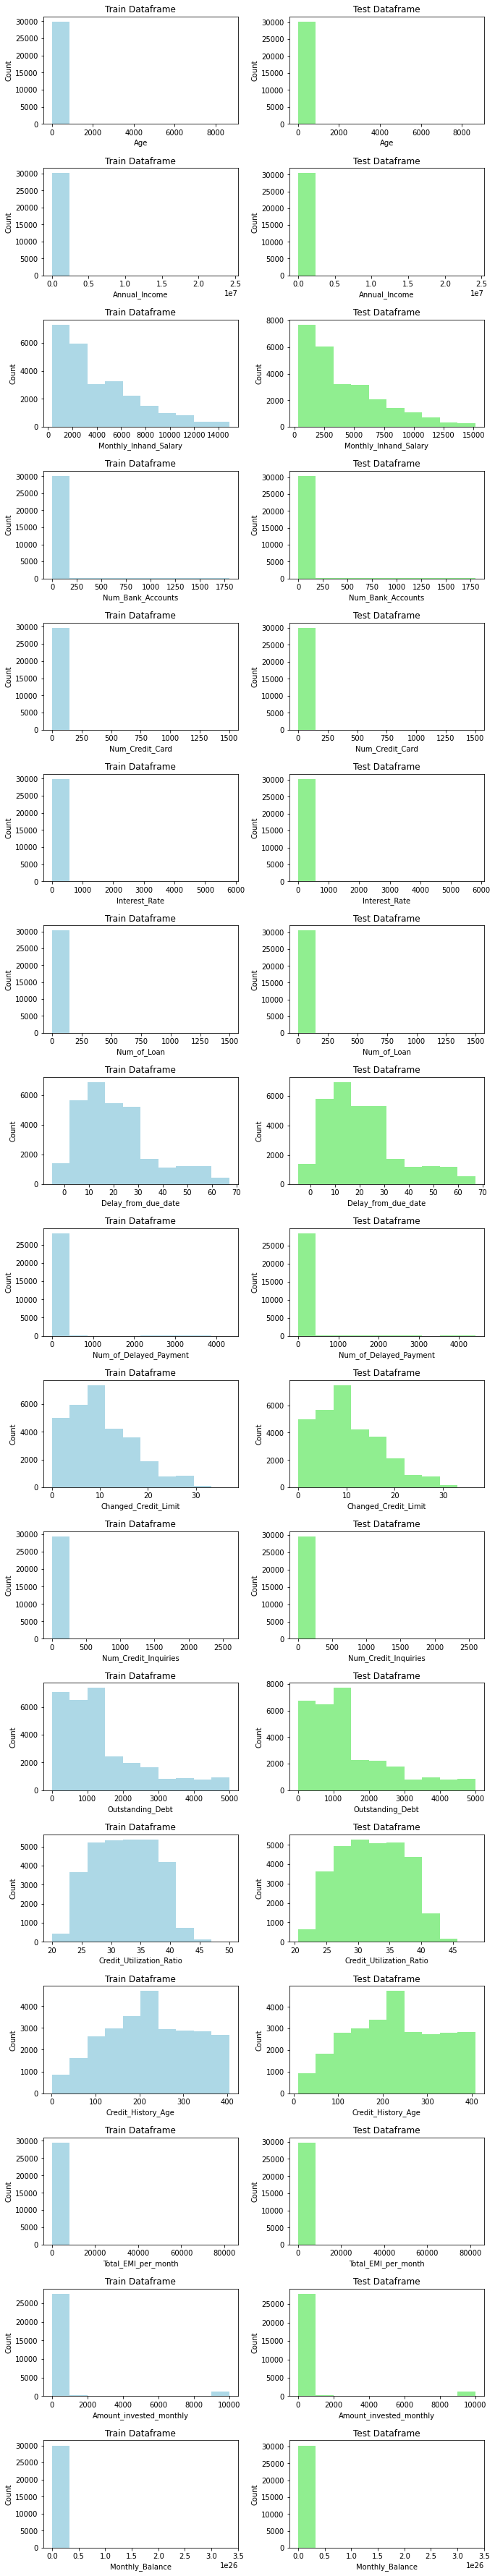

In [ ]:
# setting plot layout
fig, axes = plt.subplots(17, 2, figsize = (10, 50))
fig.tight_layout(pad = 4)

# plotting the data visualization
for i in range(len(NumFeatures)):
    axes[i, 0].hist(train[NumFeatures[i]],
                    color = 'lightblue')
    axes[i, 0].set_title('Train Dataframe')
    axes[i, 0].set_xlabel(NumFeatures[i])
    axes[i, 0].set_ylabel('Count')
    axes[i, 1].hist(test[NumFeatures[i]],
                    color = 'lightgreen')
    axes[i, 1].set_title('Test Dataframe')
    axes[i, 1].set_xlabel(NumFeatures[i])
    axes[i, 1].set_ylabel('Count')
plt.show()

In [ ]:
# counting the outliers in Annual_Income
countoutlier(train, 'Annual_Income')
countoutlier(test, 'Annual_Income')


Outlier count in Annual_Income : 838
Outlier count in Annual_Income : 855


Annual_Income  data distribution after dropping the outliers : 


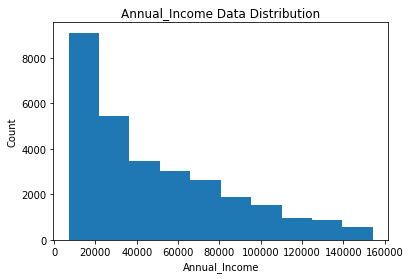

In [ ]:
# dropping the outliers in Train dataframe's Annual_Income
omitoutlier(train, 'Annual_Income')

Annual_Income  data distribution after dropping the outliers : 


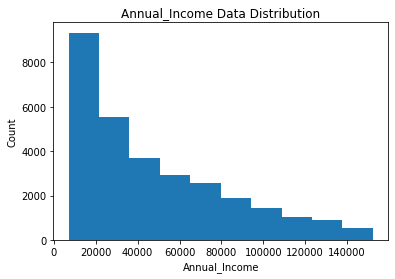

In [ ]:
# dropping the outliers in Test dataframe's Annual_Income
omitoutlier(test, 'Annual_Income')